In [1]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline

from xgboost import XGBClassifier

import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("../data/kidney_disease.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (400, 26)


In [3]:
# ============================================
# INITIAL DATASET INSPECTION
# ============================================

print("First 5 rows:")
display(df.head())

First 5 rows:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(400, 26)

Column Names:
['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Data Types:
id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                   str
pc                    str
pcc                   str
ba                    str
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                   str
wc                    str
rc                    str
htn                   str
dm                    str
cad                   str
appet                 str
pe                    str
ane                   str
classification        str
dtype: object


In [5]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    str    
 17  wc              295 non-n

In [6]:
# ============================================
# INSPECT THE TARGET VARIABLE
# ============================================

print("Unique classification values:")
print(df["classification"].unique())

print("\nClassification counts:")
print(df["classification"].value_counts(dropna=False))

Unique classification values:
<StringArray>
['ckd', 'ckd\t', 'notckd']
Length: 3, dtype: str

Classification counts:
classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


In [7]:
# ============================================
# DATA CLEANING
# ============================================

# Clean column names
df.columns = df.columns.str.strip()

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


In [8]:
# Clean text columns
for column in df.select_dtypes(include=["object", "string"]).columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

print("Text columns cleaned successfully.")

Text columns cleaned successfully.


In [9]:
# Replace common missing-value symbols
df = df.replace(
    ["?", "nan", "none", ""],
    np.nan
)

print("Missing-value symbols converted to NaN.")

Missing-value symbols converted to NaN.


In [10]:
# Columns that should contain numerical values
numeric_columns = [
    "age",
    "bp",
    "sg",
    "al",
    "su",
    "bgr",
    "bu",
    "sc",
    "sod",
    "pot",
    "hemo",
    "pcv",
    "wc",
    "rc"
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

print("Numerical columns converted successfully.")

Numerical columns converted successfully.


In [11]:
# ============================================
# CLEAN THE TARGET VARIABLE
# ============================================

df["classification"] = (
    df["classification"]
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "", regex=True)
)

df["classification"] = df["classification"].replace({
    "ckd": 1,
    "notckd": 0
})

# Remove rows with invalid or missing target values
df = df.dropna(
    subset=["classification"]
)

# Convert target to integer
df["classification"] = df["classification"].astype(int)

print("Target variable cleaned successfully.")

print("\nTarget values:")
print(df["classification"].value_counts())

Target variable cleaned successfully.

Target values:
classification
1    250
0    150
Name: count, dtype: int64


In [12]:
# ============================================
# REMOVE UNNECESSARY COLUMNS
# ============================================

if "id" in df.columns:
    df = df.drop(columns=["id"])

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


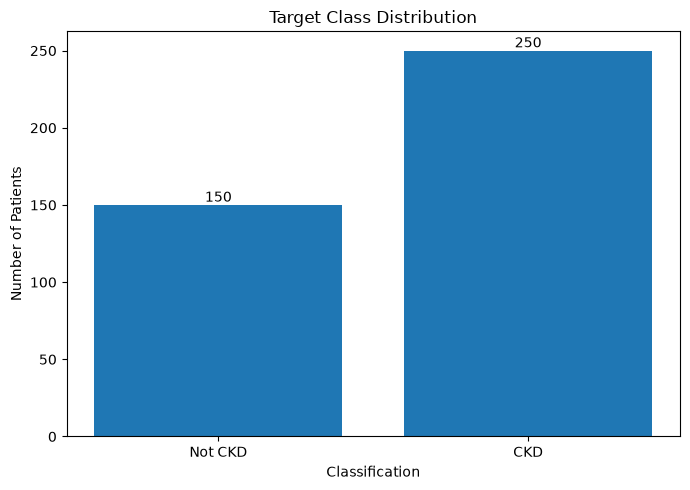

In [13]:
# ============================================
# EXPLORATORY DATA ANALYSIS - TARGET DISTRIBUTION
# ============================================

class_counts = df["classification"].value_counts().sort_index()

labels = ["Not CKD", "CKD"]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    labels,
    class_counts.values
)

plt.title("Target Class Distribution")
plt.xlabel("Classification")
plt.ylabel("Number of Patients")

for bar, value in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

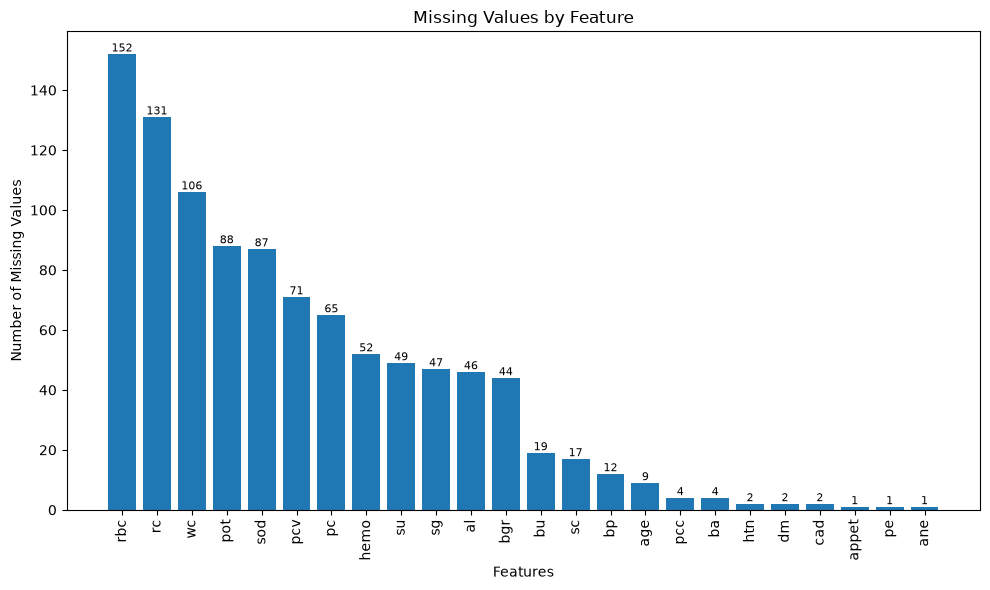

In [14]:
# ============================================
# MISSING VALUES ANALYSIS
# ============================================

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    missing_values.index,
    missing_values.values
)

plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")

plt.xticks(
    rotation=90
)

for bar, value in zip(bars, missing_values.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [15]:
# ============================================
# MISSING VALUE SUMMARY
# ============================================

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values(
    "Missing Values",
    ascending=False
)

display(missing_summary)

,Missing Values,Missing Percentage
rbc,152,38.00
rc,131,32.75
wc,106,26.50
pot,88,22.00
sod,87,21.75
pcv,71,17.75
pc,65,16.25
hemo,52,13.00
su,49,12.25
sg,47,11.75


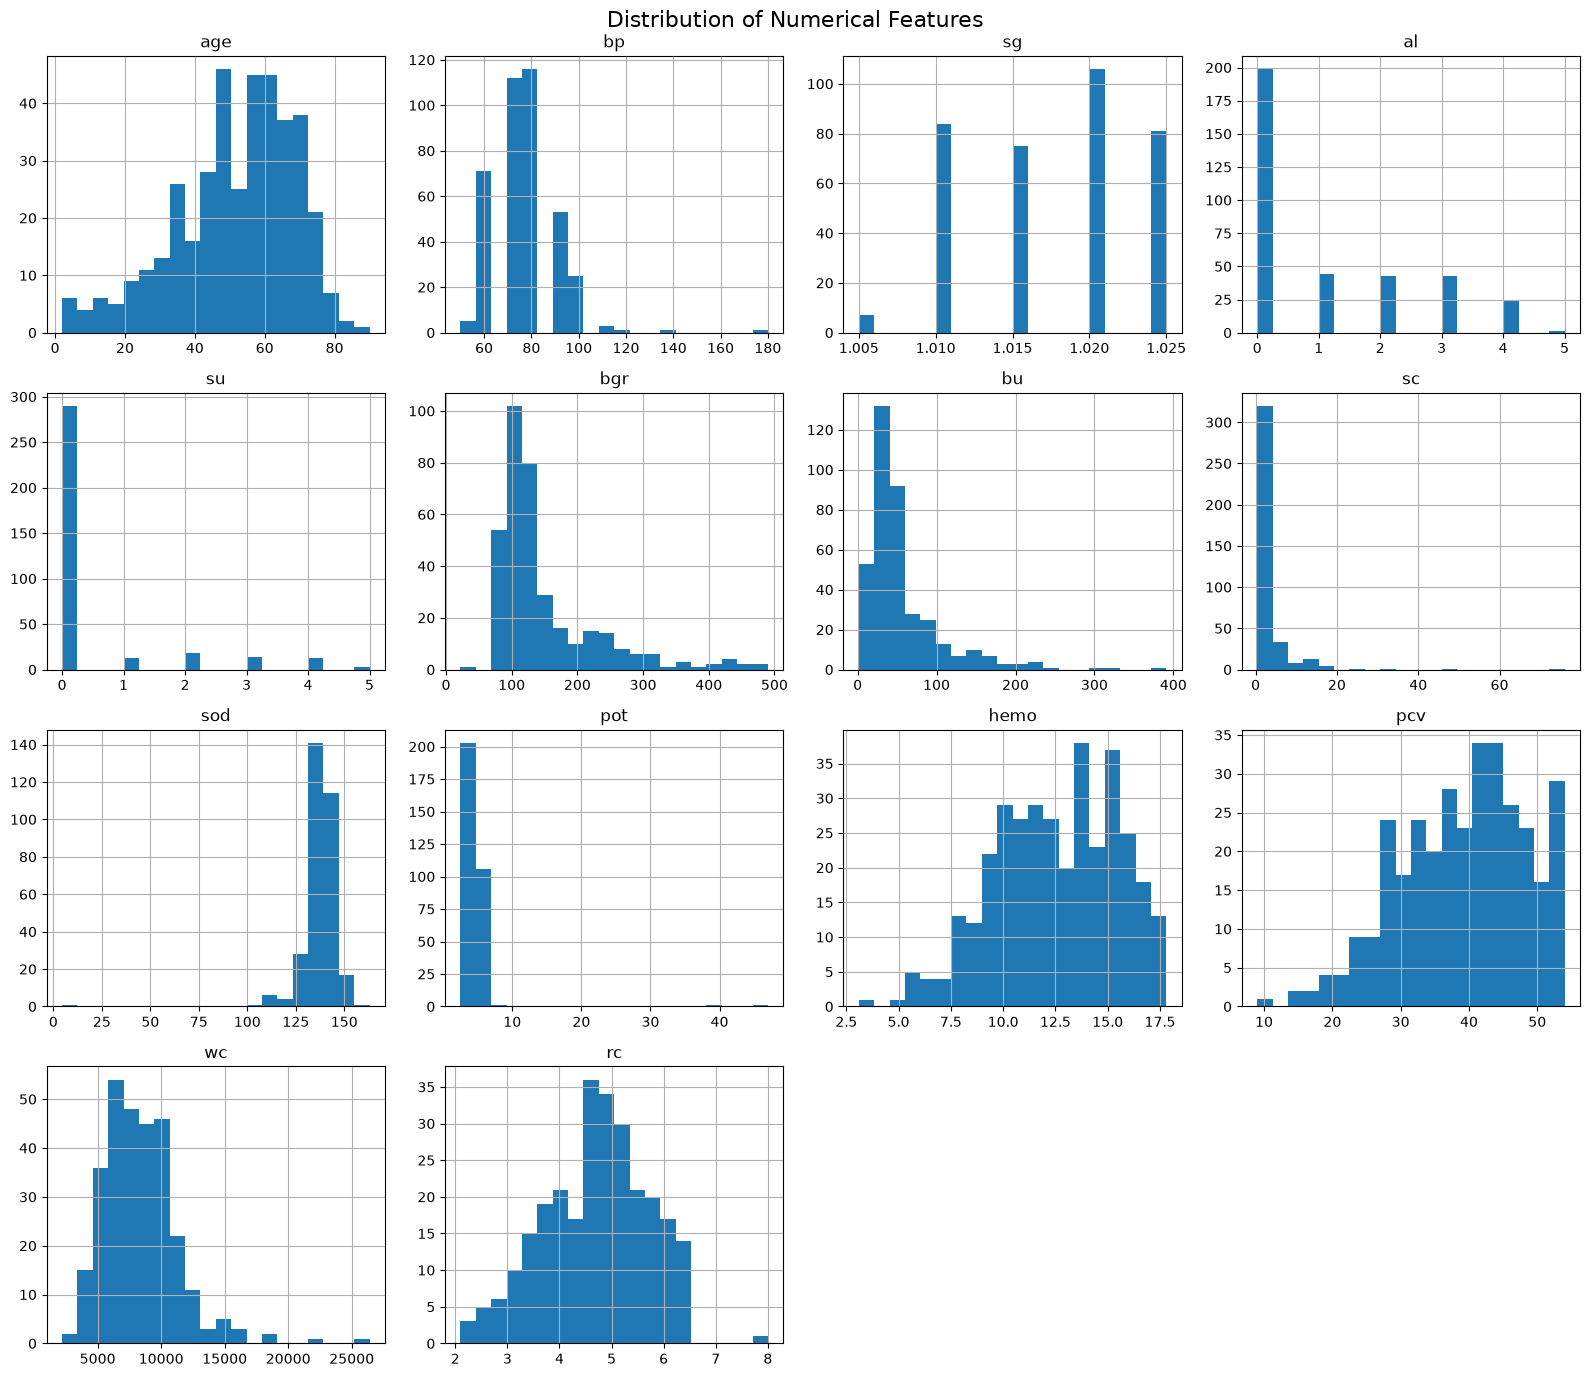

In [16]:
# ============================================
# NUMERICAL FEATURES DISTRIBUTION
# ============================================

available_numeric = [
    column for column in numeric_columns
    if column in df.columns
]

df[available_numeric].hist(
    figsize=(16, 14),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

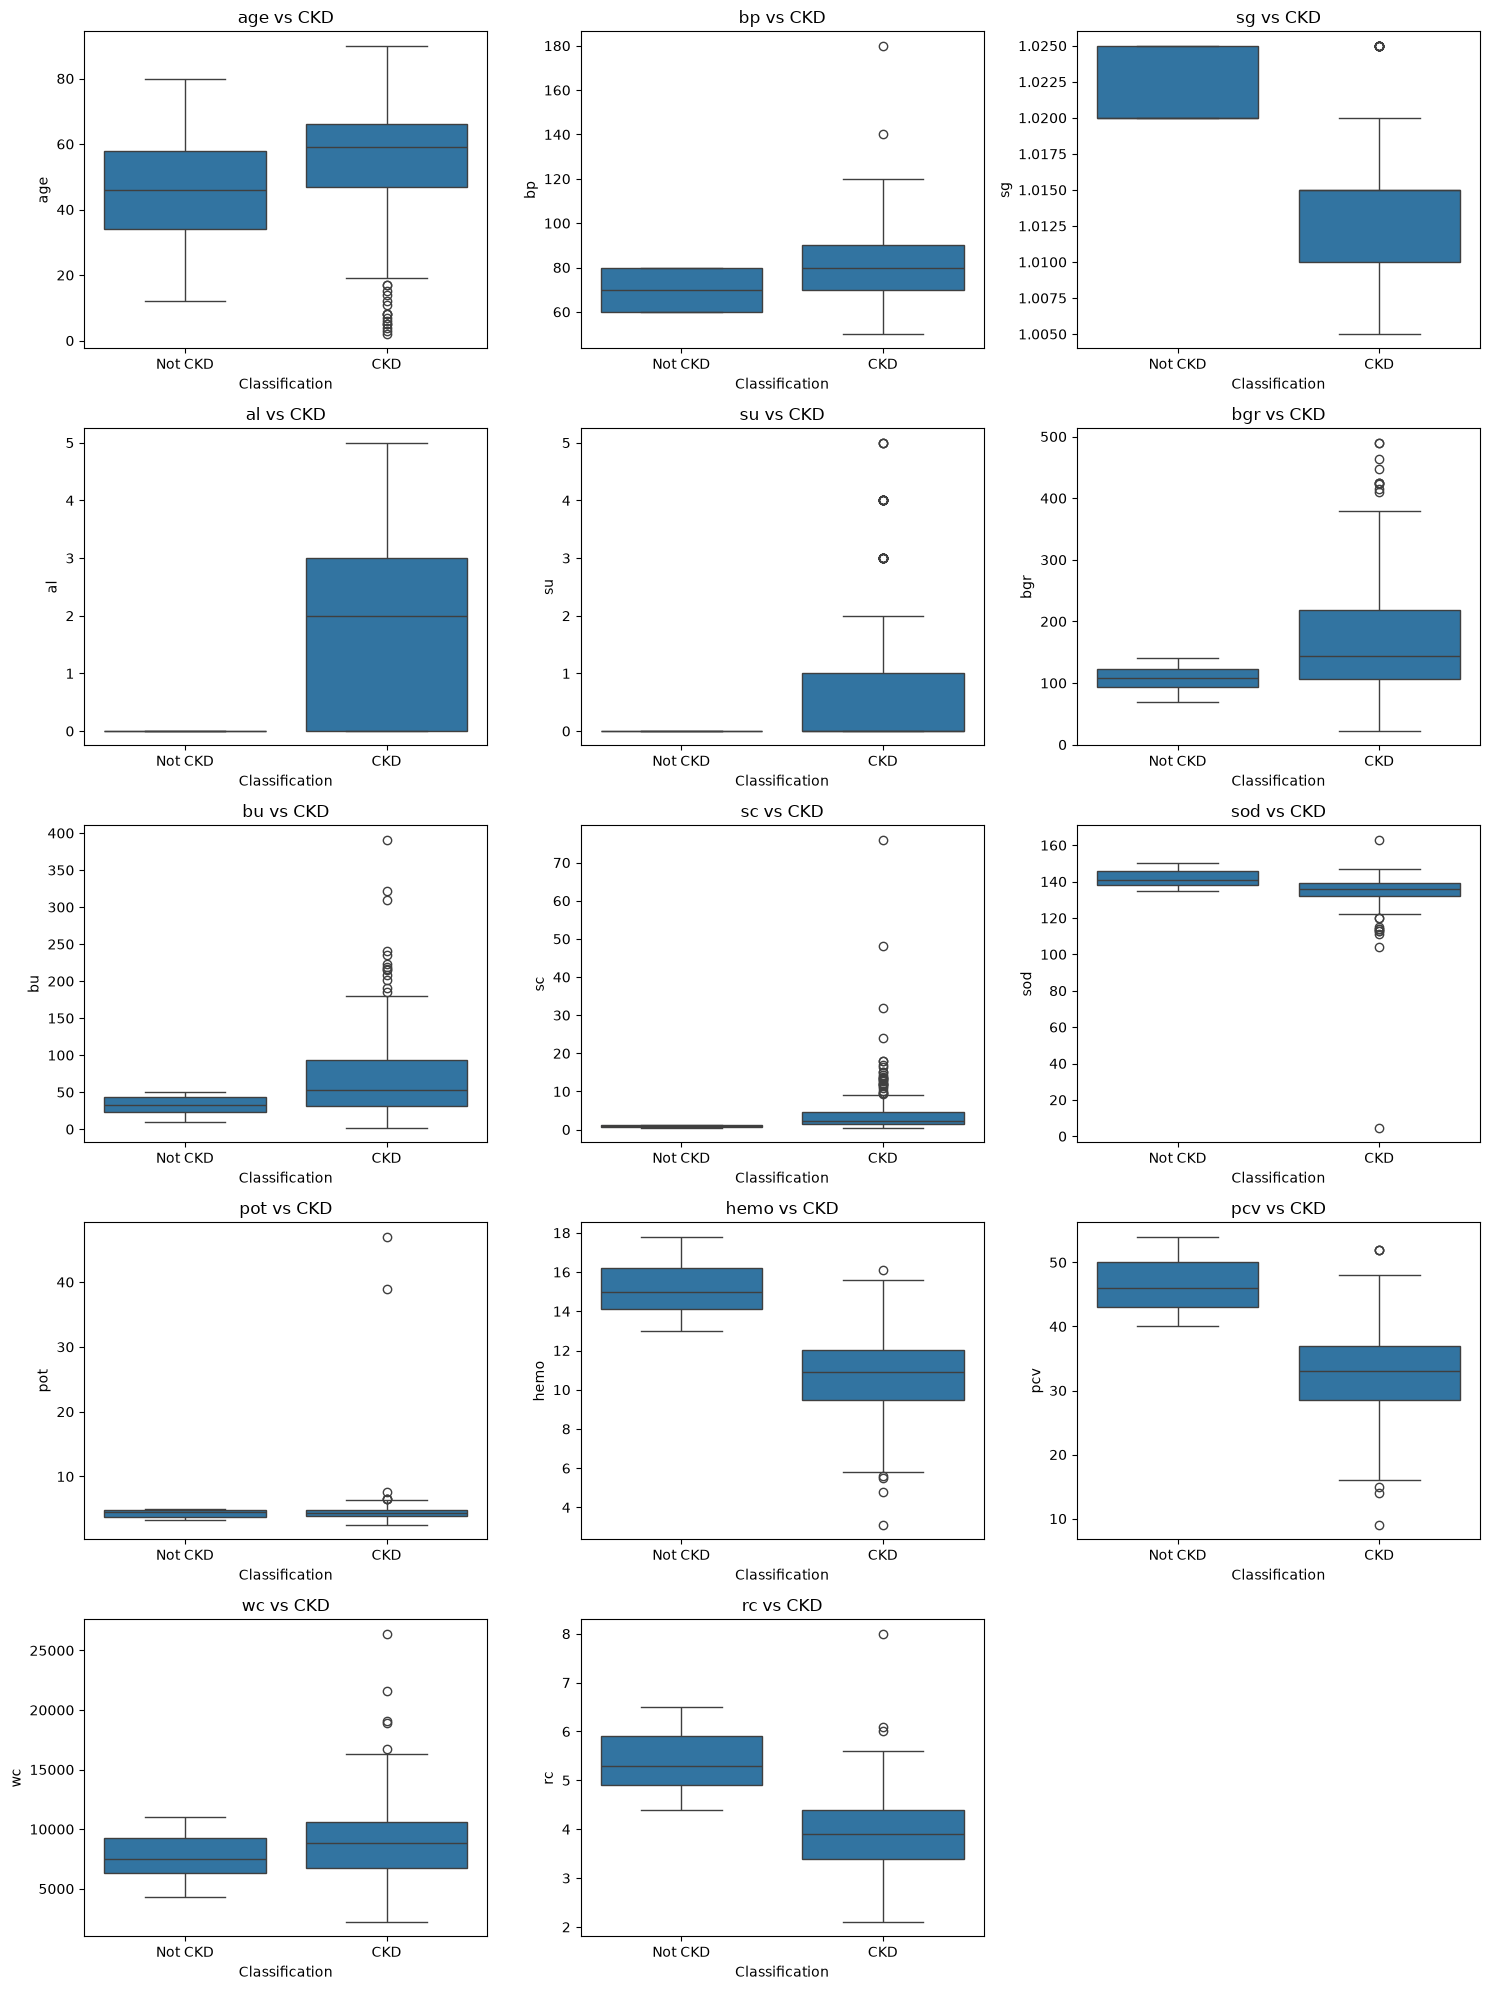

In [19]:
# ============================================
# NUMERICAL FEATURES BY CKD CLASSIFICATION
# ============================================

plot_numeric = [
    column for column in available_numeric
    if df[column].notna().sum() > 0
]

n_columns = 3
n_rows = int(np.ceil(len(plot_numeric) / n_columns))

fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(15, n_rows * 4)
)

axes = np.array(axes).reshape(-1)

for ax, column in zip(axes, plot_numeric):

    sns.boxplot(
        data=df,
        x="classification",
        y=column,
        ax=ax
    )

    ax.set_title(f"{column} vs CKD")
    ax.set_xlabel("Classification")
    ax.set_ylabel(column)

    ax.set_xticks([0, 1], labels=["Not CKD", "CKD"])

for ax in axes[len(plot_numeric):]:
    ax.remove()

plt.tight_layout()
plt.show()


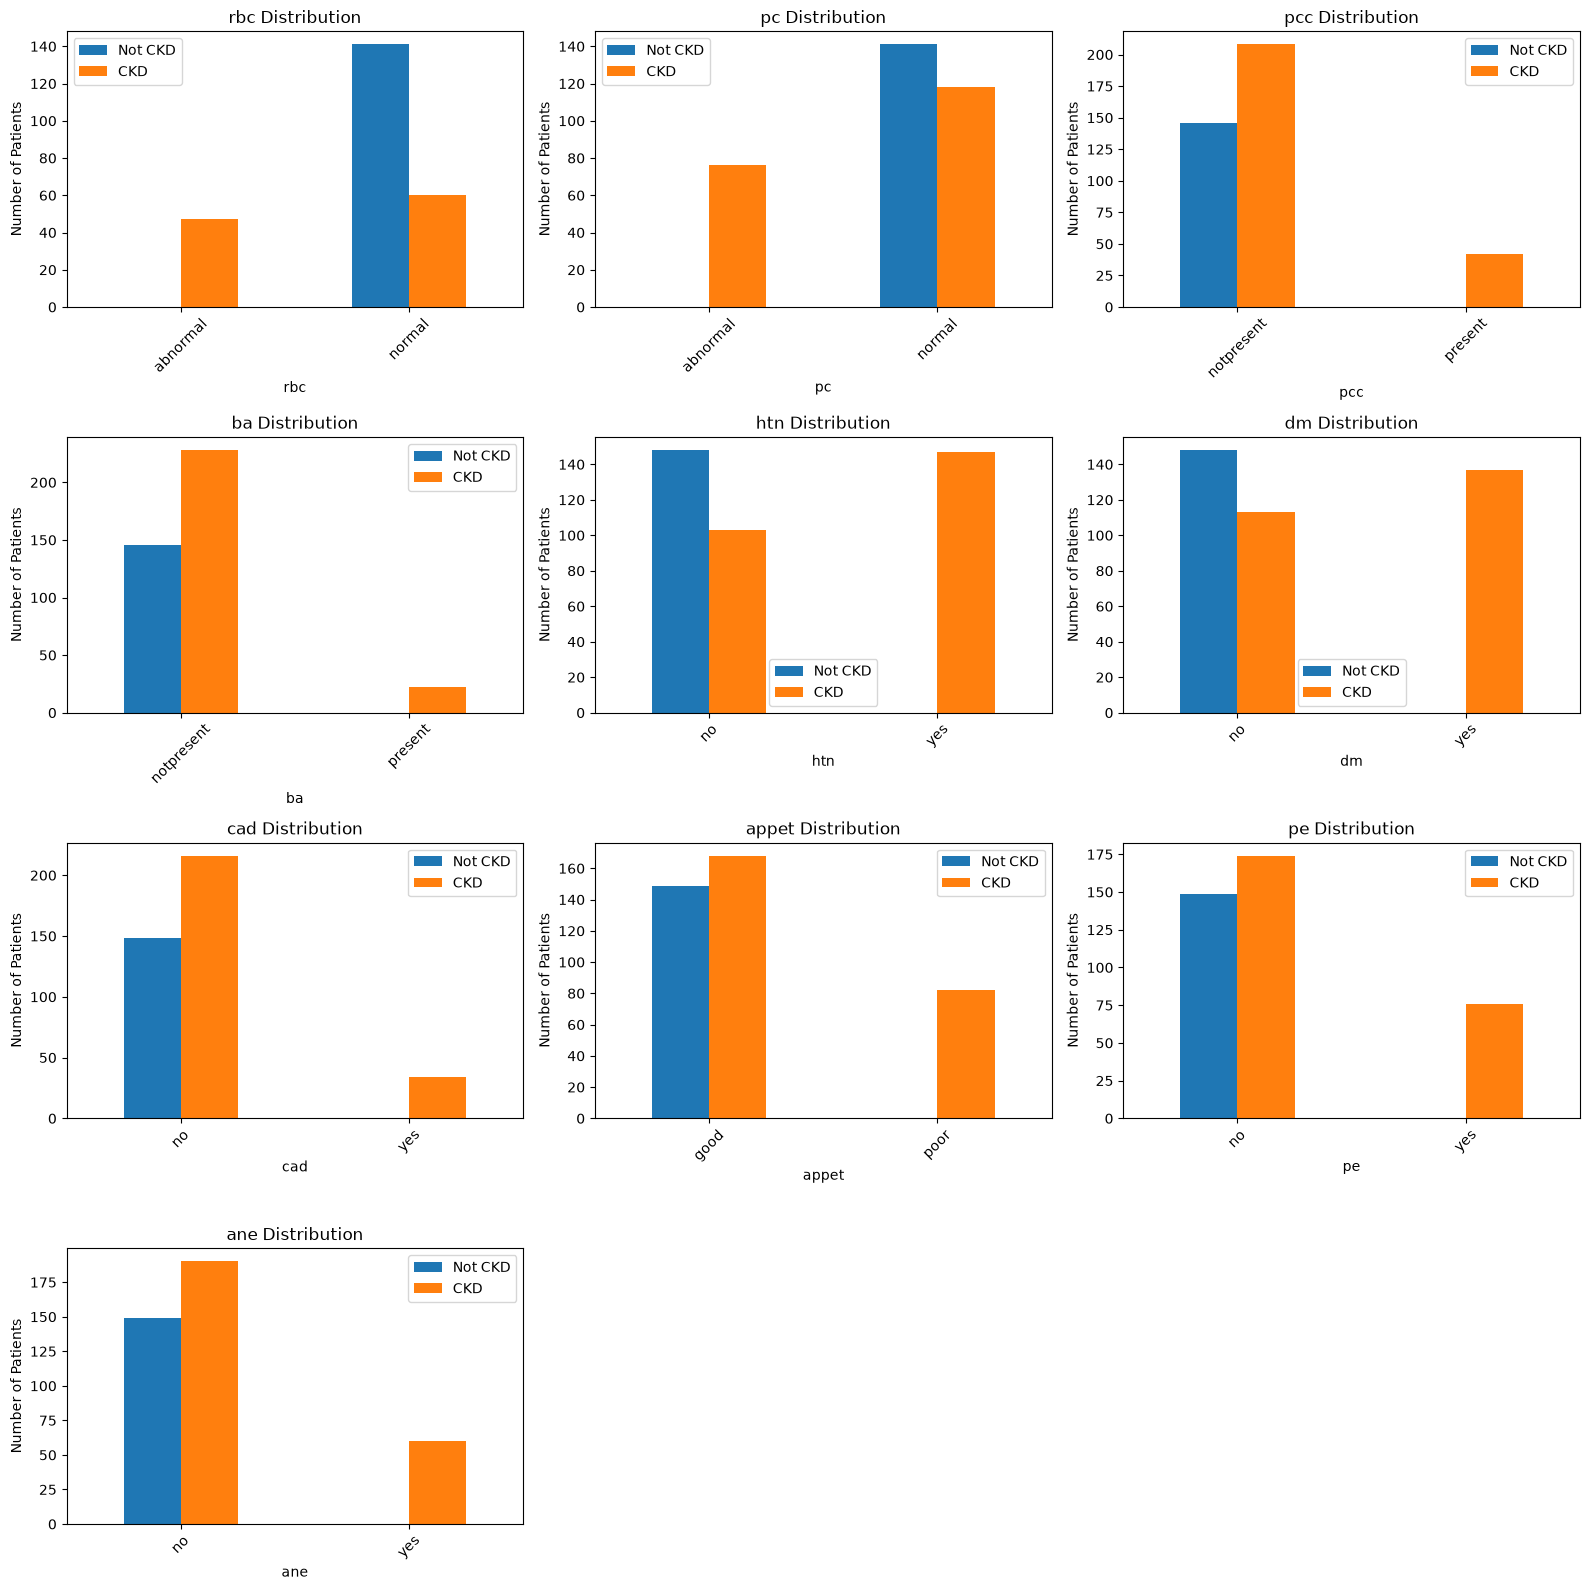

In [20]:
# ============================================
# CATEGORICAL FEATURES DISTRIBUTION
# ============================================

categorical_columns = [
    column
    for column in df.select_dtypes(
        include=["object", "string", "category"]
    ).columns
    if column != "classification"
]

n_columns = 3
n_rows = int(np.ceil(len(categorical_columns) / n_columns))

fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(16, n_rows * 4)
)

axes = np.array(axes).reshape(-1)

for ax, column in zip(axes, categorical_columns):

    cross_table = pd.crosstab(
        df[column],
        df["classification"]
    )

    cross_table.columns = [
        "Not CKD" if value == 0 else "CKD"
        for value in cross_table.columns
    ]

    cross_table.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(f"{column} Distribution")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of Patients")
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(categorical_columns):]:
    ax.remove()

plt.tight_layout()
plt.show()

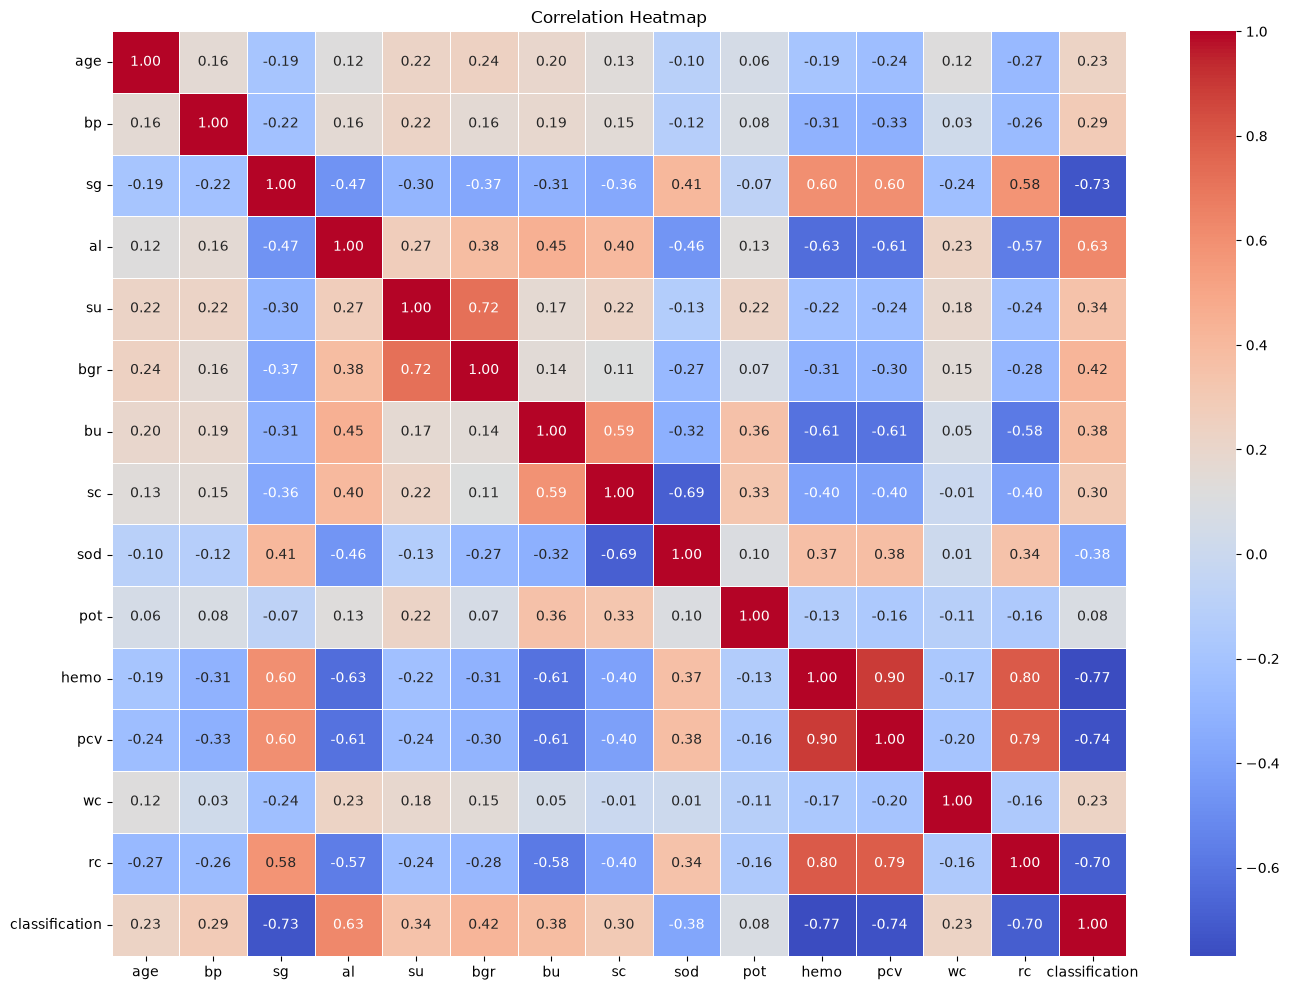

In [21]:
# ============================================
# CORRELATION ANALYSIS
# ============================================

correlation_data = df[
    available_numeric + ["classification"]
].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [22]:
# ============================================
# SEPARATE FEATURES AND TARGET VARIABLE
# ===========================================

X = df.drop(
    columns=["classification"]
)

y = df["classification"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (400, 24)
y shape: (400,)

Target distribution:
classification
1    250
0    150
Name: count, dtype: int64


In [23]:
# ============================================
# TRAIN-TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (320, 24)
X_test : (80, 24)
y_train: (320,)
y_test : (80,)


In [24]:
# ============================================
# IDENTIFY CATEGORICAL AND NUMERICAL FEATURES
# ============================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']

Categorical Features:
['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [25]:
# ============================================
# DATA PREPROCESSING 
# ===========================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)

In [26]:
# ============================================
# COMBINE CATEGORICAL AND NUMERICAL PREPROCESSING
# ============================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [27]:
# ============================================
# PREPARE SMOTENC
# ============================================

categorical_indices = list(
    range(
        len(numeric_features),
        len(numeric_features) + len(categorical_features)
    )
)

print("SMOTENC categorical indices:")
print(categorical_indices)

SMOTENC categorical indices:
[14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [28]:
# ============================================
# DEFINE THE XGBOOST CLASSIFICATION MODEL
# ============================================

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print("XGBoost model created successfully.")

XGBoost model created successfully.


In [29]:
# ============================================
# BUILD THE COMPLETE PIPELINE
# ============================================

smote = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42
)

pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "smotenc",
            smote
        ),
        (
            "xgboost",
            model
        )
    ]
)

print("Complete pipeline created successfully.")

Complete pipeline created successfully.


In [30]:
# ============================================
# TRAIN THE MODEL
# ============================================

print("Training XGBoost with SMOTENC...")

pipeline.fit(
    X_train,
    y_train
)

print("Training completed successfully.")

Training XGBoost with SMOTENC...
Training completed successfully.


In [31]:
# ============================================
# MAKE PREDICTIONS ON TEST DATA
# ============================================

y_pred = pipeline.predict(
    X_test
)

y_probability = pipeline.predict_proba(
    X_test
)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [32]:
# ============================================
# CALCULATE EVALUATION METRICS
# ============================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("Metrics calculated successfully.")

Metrics calculated successfully.


In [33]:
# ============================================
# FINAL MODEL PERFORMANCE
# ============================================

print("================================")
print("FINAL XGBOOST RESULTS")
print("================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

FINAL XGBOOST RESULTS
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000


In [34]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not CKD",
            "CKD"
        ],
        zero_division=0
    )
)

Classification Report:
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [35]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[30  0]
 [ 0 50]]


<Figure size 700x600 with 0 Axes>

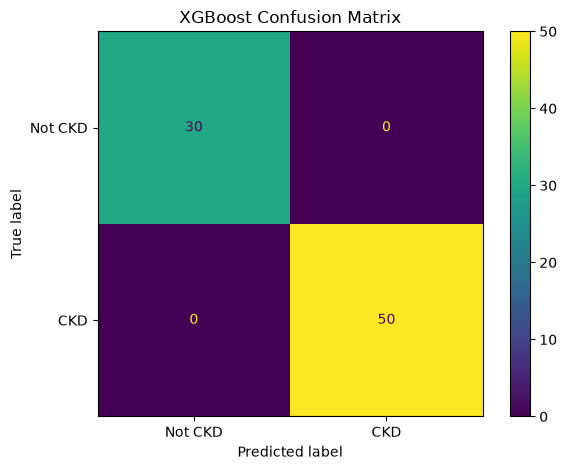

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not CKD", "CKD"]
).plot()

plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

In [37]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_importances = pipeline.named_steps[
    "xgboost"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
11,numeric__pcv,0.259081
10,numeric__hemo,0.237598
2,numeric__sg,0.111048
3,numeric__al,0.091567
18,categorical__htn,0.083513
19,categorical__dm,0.083176
7,numeric__sc,0.044803
13,numeric__rc,0.032506
6,numeric__bu,0.015281
5,numeric__bgr,0.012862


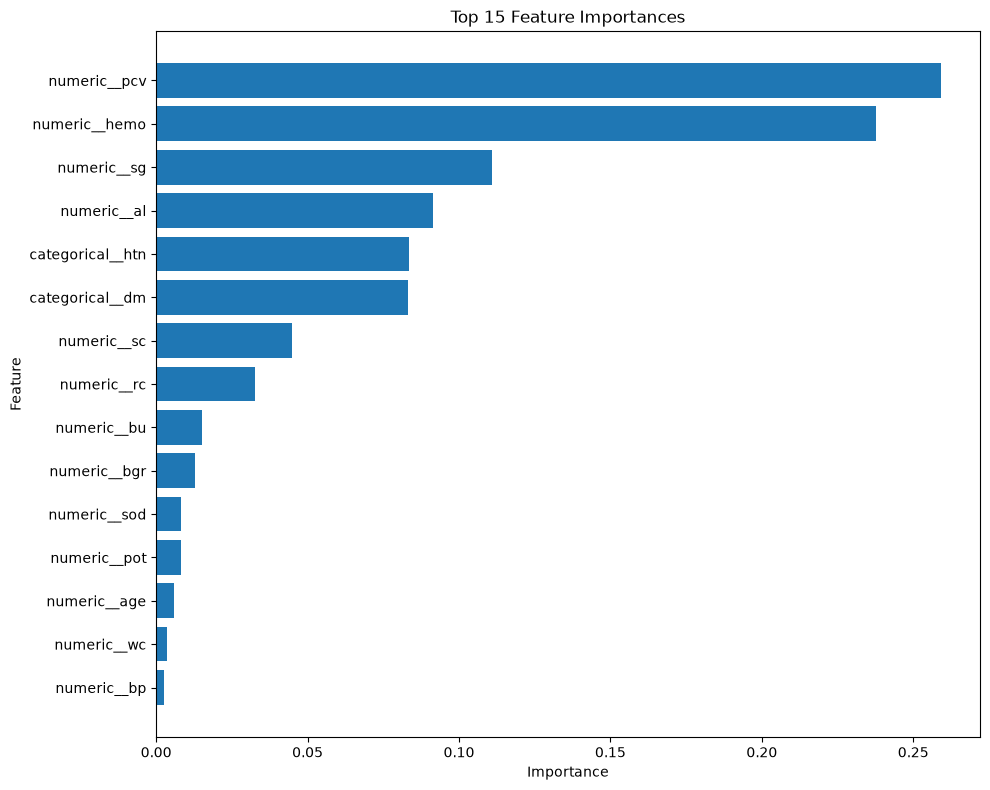

In [38]:
plt.figure(figsize=(10, 8))

top_features = importance_df.head(15)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

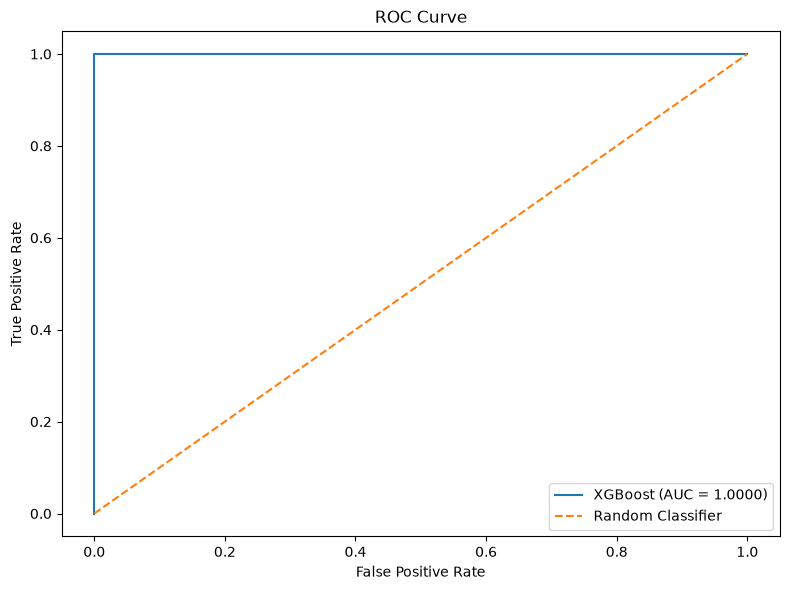

In [39]:
# ============================================
# ROC CURVE
# ============================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.tight_layout()
plt.show()

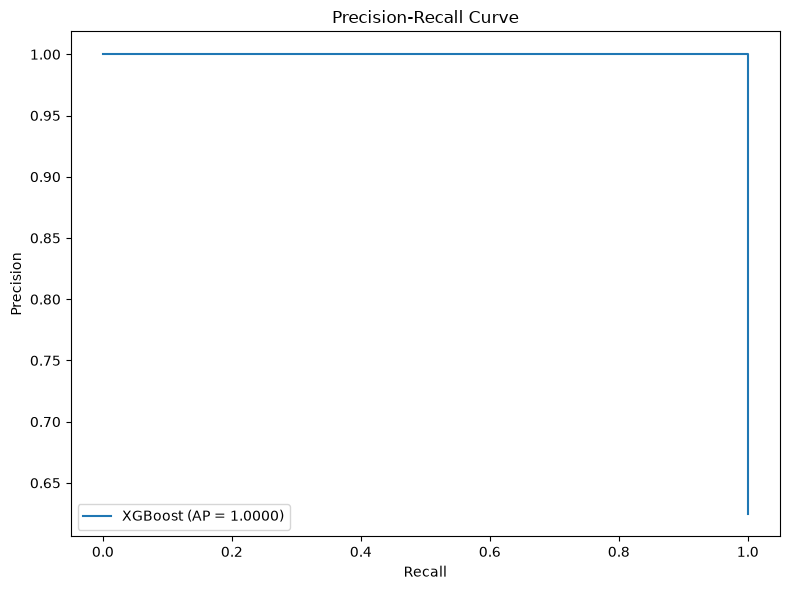

In [40]:
# ============================================
# PRECISION-RECALL CURVE
# ============================================

precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    y_probability
)

average_precision = average_precision_score(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"XGBoost (AP = {average_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.tight_layout()
plt.show()

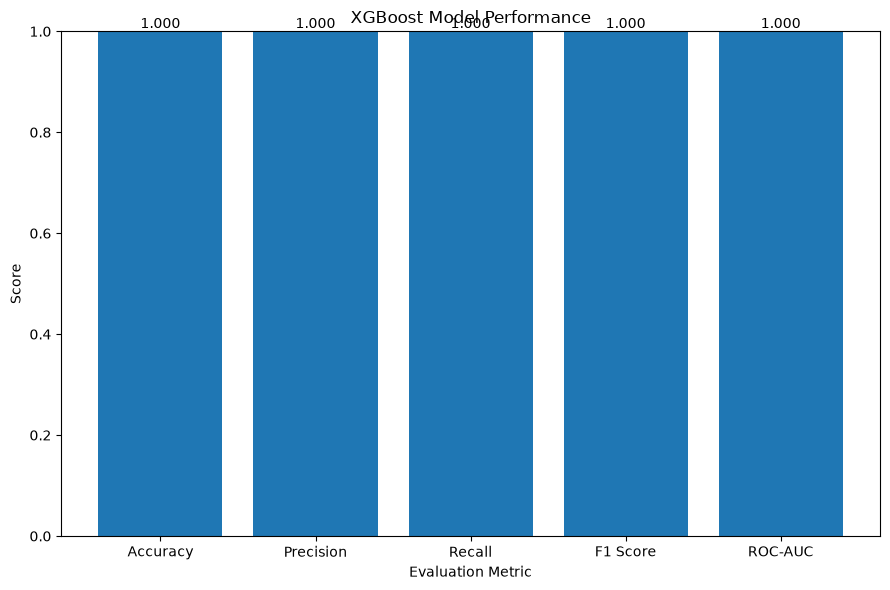

In [42]:
# ============================================
# MODEL PERFORMANCE COMPARISON
# ============================================

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}

plt.figure(figsize=(9, 6))

bars = plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.title("XGBoost Model Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.ylim(0, 1)

for bar, value in zip(
    bars,
    metrics.values()
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [43]:
# ============================================
# FINAL MODEL SUMMARY
# ============================================

print("==========================================")
print("FINAL MODEL SUMMARY")
print("==========================================")

print("Model: XGBoost Classifier")
print("Sampling Technique: SMOTENC")
print("Test Size: 20%")
print("Random State: 42")

print("\nPerformance:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

FINAL MODEL SUMMARY
Model: XGBoost Classifier
Sampling Technique: SMOTENC
Test Size: 20%
Random State: 42

Performance:
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000


In [44]:
# ============================================
# SAVE THE TRAINED MODEL
# ============================================

MODEL_PATH = Path(
    "../backend/models/ckd_model.pkl"
)

MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

model_package = {
    "pipeline": pipeline,
    "features": X.columns.tolist(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "model_name": "XGBoost",
    "metrics": {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(roc_auc)
    }
}

joblib.dump(
    model_package,
    MODEL_PATH
)

print("Model saved successfully!")
print("Model path:")
print(MODEL_PATH)

Model saved successfully!
Model path:
..\backend\models\ckd_model.pkl


In [45]:
# ============================================
# VERIFY THE SAVED MODEL
# ============================================

saved_model = joblib.load(
    MODEL_PATH
)

print("Saved model loaded successfully.")

print("\nStored information:")
print(saved_model.keys())

Saved model loaded successfully.

Stored information:
dict_keys(['pipeline', 'features', 'numeric_features', 'categorical_features', 'model_name', 'metrics'])
